In [1]:
import numpy as np
import pandas as pd

import os

from PIL import Image

In [2]:
def get_count(dir_path):
    count = 0
    for path in os.listdir(dir_path):
        count += 1
    
    print('Original Images count:', count)
    print('Tampered Images count:', count)


print('Training data:')
get_count('../input/cg1050/TRAINING_CG-1050/TRAINING/ORIGINAL')

print('\nValidation data:')
get_count('../input/cg1050/VALIDATION_CG-1050/VALIDATION/ORIGINAL')

Training data:
Original Images count: 730
Tampered Images count: 730

Validation data:
Original Images count: 314
Tampered Images count: 314


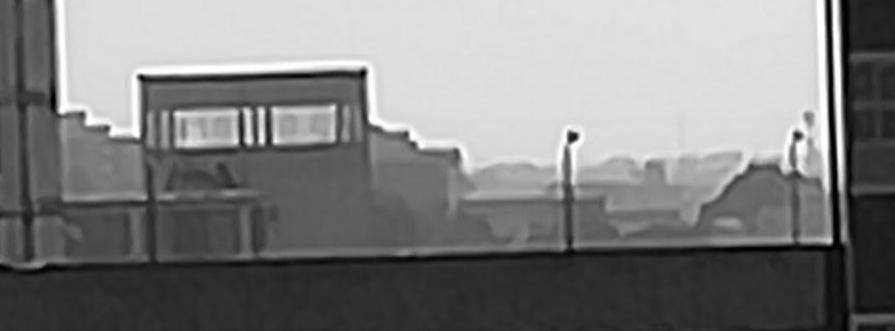

In [3]:
original = Image.open('../input/cg1050/TRAINING_CG-1050/TRAINING/ORIGINAL/Im100_2_cm.jpg')
original

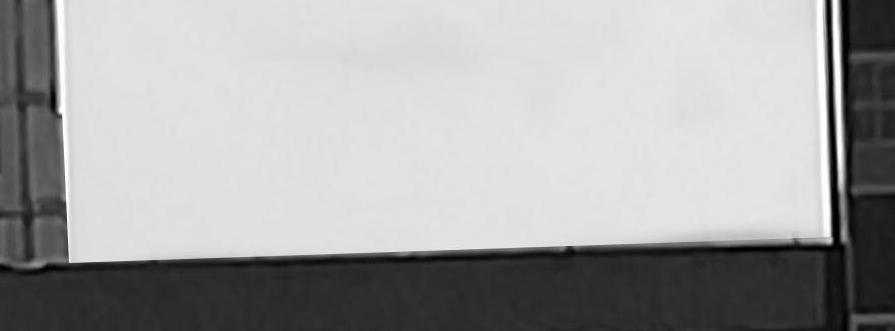

In [4]:
tampered = Image.open('../input/cg1050/TRAINING_CG-1050/TRAINING/TAMPERED/Im100_cm2.jpg')
tampered

In [5]:
from keras.preprocessing.image import ImageDataGenerator

img_shape = (150,150)

datagen = ImageDataGenerator()

training_data = datagen.flow_from_directory('../input/cg1050/TRAINING_CG-1050/TRAINING/',
                                            target_size=img_shape,
                                            color_mode='rgb',
                                            batch_size=64,
                                            seed=32,
                                            interpolation='bicubic')

validation_data = datagen.flow_from_directory('../input/cg1050/VALIDATION_CG-1050/VALIDATION/',
                                                    target_size=img_shape,
                                                    color_mode='rgb',
                                                    batch_size=64,
                                                    seed=32,
                                                    interpolation='bicubic')

Found 1460 images belonging to 2 classes.
Found 628 images belonging to 2 classes.


In [6]:
import keras.models as M
import keras.layers as L
from tensorflow_addons.layers import InstanceNormalization as IN

def make_model():
    model=M.Sequential()
    model.add(L.Conv2D(filters=32,kernel_size=(3,3),padding='same',strides=2,activation="relu",input_shape=(150,150,3)))
    model.add(IN(axis=-1))
    model.add(L.MaxPooling2D(pool_size=(2,2)))
    model.add(L.Conv2D(filters=64,kernel_size=(3,3),padding='same',strides=2))
    model.add(L.MaxPooling2D(pool_size=(2,2)))
    model.add(L.Dropout(0.4))
    model.add(L.Conv2D(filters=128,kernel_size=(3,3),padding='same',strides=2))
    model.add(L.MaxPooling2D(pool_size=(2,2)))
    model.add(L.Flatten())
    model.add(L.Dense(100,'relu'))
    model.add(L.Dropout(0.4))
    model.add(L.Dense(2,'softmax'))
    model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
    return model

model=make_model()
model.summary()

2022-06-03 07:26:35.441074: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 75, 75, 32)        896       
_________________________________________________________________
instance_normalization (Inst (None, 75, 75, 32)        64        
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 37, 37, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 19, 19, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 9, 9, 64)          0         
_________________________________________________________________
dropout (Dropout)            (None, 9, 9, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 5, 5, 128)         7

In [7]:
early_stop=keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=4)
reduce_lr=keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',patience=2)
model.fit(training_data,validation_data=validation_data,epochs=40,callbacks=[early_stop,reduce_lr])

NameError: name 'keras' is not defined

In [ ]:
import matplotlib.pyplot as plt

loss=model.history.history['loss']
val_loss=model.history.history['val_loss']
acc=model.history.history['accuracy']
val_acc=model.history.history['val_accuracy']
epochs=[i for i in range(len(loss))]
plt.plot(epochs,loss)
plt.plot(epochs,val_loss)
plt.show();

In [ ]:
plt.plot(epochs,acc)
plt.plot(epochs,val_acc)
plt.show();

In [ ]:
import cv2

def predict_image(path):
    image=cv2.imread(path)
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    image=cv2.resize(image,(150,150))
    image=image.reshape(1,150,150,3)
    prediction=np.argmax(model.predict(image))
    labels=['Tampered','Original']
    return labels[prediction]

In [ ]:
predict_image('../input/cg1050/VALIDATION_CG-1050/VALIDATION/ORIGINAL/Im100_1_cm.jpg')

In [ ]:
predict_image('../input/cg1050/VALIDATION_CG-1050/VALIDATION/TAMPERED/Im100_cm1.jpg')